# Non-Hermitian Lattice Theory
## Tight-Binding Formulation and Spectral Properties

This work develops a theoretical framework for non-Hermitian tight-binding lattice systems.
Hamiltonians are constructed from first principles with explicit emphasis on non-reciprocal
couplings and complex-valued parameters. The resulting spectral structure is analyzed in terms
of complex energy eigenvalues and the spatial localization properties of eigenstates, including
boundary-induced phenomena characteristic of non-Hermitian systems.

The formulation presented here provides the theoretical basis for subsequent numerical
calculations and figures, which are intended to support a quantitative investigation of
non-Hermitian lattice physics.

Non-Hermitian Hamiltonians provide an effective theoretical description of open
photonic systems with gain and loss and are widely employed in photonics and wave
physics (El-Ganainy et al., 2018).

## Physical Model

We study a one-dimensional dimerized tight-binding lattice of the
Su-Schrieffer-Heeger (SSH) type with explicitly introduced non-Hermiticity.
The lattice consists of two sublattices, denoted A and B, within each unit cell.
Nearest-neighbor hopping is characterized by an intra-cell coupling amplitude
$t_1$ and an inter-cell coupling amplitude $t_2$.
Non-Hermiticity is incorporated through complex on-site potentials that model
spatially distributed gain and loss.

The resulting Hamiltonian is non-Hermitian and does not satisfy
$H \neq H^\dagger$.
Consequently, its spectral and eigenstate properties depart fundamentally from
those of Hermitian SSH models.

The analysis focuses on the complex energy spectrum and the structure of
eigenstates, with particular emphasis on the emergence of boundary-localized
modes and localization phenomena arising from the combined effects of topology
and non-Hermiticity.


This lattice structure corresponds to the Su-Schrieffer-Heeger model originally
introduced in the context of polyacetylene (Su, Schrieffer, and Heeger, 1979).

In [1]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
import yaml
import json
import hashlib
from pathlib import Path
from datetime import datetime

In [2]:
def load_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

CONFIG_DIR = Path("..") / "config"

global_config = load_yaml(CONFIG_DIR / "global_config.yaml")
lattice_config = load_yaml(CONFIG_DIR / "lattice_params.yaml")
simulation_config = load_yaml(CONFIG_DIR / "simulation_params.yaml")
plotting_config = load_yaml(CONFIG_DIR / "plotting_params.yaml")

NOTEBOOK_KEY = "01_theory_nonhermitian_lattices"

In [3]:
assert NOTEBOOK_KEY in plotting_config["notebook_figures"], \
    f"Missing plotting config for {NOTEBOOK_KEY}"

### Note on Simulation Parameters

This notebook performs a single-shot spectral analysis.
`simulation_config` is loaded for consistency but not used here.

In [4]:
def hash_parameters(*configs):
    combined = json.dumps(configs, sort_keys=True).encode("utf-8")
    return hashlib.sha256(combined).hexdigest()

PARAMETER_HASH = hash_parameters(lattice_config, simulation_config)
PARAMETER_HASH

'bc80a224a0f51e1329a643b1354ae28c667802092b28c27279c2911371ed5411'

## Non-Hermitian SSH Hamiltonian

The real-space tight-binding Hamiltonian is constructed as
$$
H = \sum_n \left[
t_1 \, a_n^\dagger b_n
+ t_2 \, a_{n+1}^\dagger b_n
+ \mathrm{h.c.}
\right]
+ \sum_n \left(
i \gamma_a \, a_n^\dagger a_n
- i \gamma_b \, b_n^\dagger b_n
\right).
$$

Here, $a_n$ and $b_n$ denote annihilation operators on the A and B sublattices,
respectively. The parameters $\gamma_a$ and $\gamma_b$ control sublattice-dependent
gain and loss, thereby introducing non-Hermiticity through an explicit asymmetry
in the on-site potentials.

Open boundary conditions are imposed, enabling the emergence of boundary-localized
eigenstates and allowing direct examination of edge phenomena in the non-Hermitian
regime.

This notebook does not yet define or compute topological invariants.
The Hamiltonian is analyzed purely spectrally.
Topological characterization is deferred to Notebook 02.

In [5]:
def build_nonhermitian_ssh_hamiltonian(
    num_cells,
    t1,
    t2,
    gamma_a,
    gamma_b
):
    # Building a real-space non-Hermitian SSH Hamiltonian with open boundaries.
    
    dim = 2 * num_cells
    H = np.zeros((dim, dim), dtype=np.complex128)

    for n in range(num_cells):
        a = 2 * n
        b = 2 * n + 1

        # On-site gain/loss
        H[a, a] = 1j * gamma_a
        H[b, b] = -1j * gamma_b

        # Intra-cell hopping
        H[a, b] = t1
        H[b, a] = t1

        # Inter-cell hopping
        if n < num_cells - 1:
            H[a + 2, b] = t2
            H[b, a + 2] = t2

    return H

In [6]:
num_cells = lattice_config["lattice"]["num_unit_cells"]
t1 = lattice_config["couplings"]["intra_cell"]
t2 = lattice_config["couplings"]["inter_cell"]

gamma_a = lattice_config["non_hermiticity"]["gain"]["strength"]
gamma_b = lattice_config["non_hermiticity"]["loss"]["strength"]

H = build_nonhermitian_ssh_hamiltonian(num_cells, t1, t2, gamma_a, gamma_b)
eigvals, eigvecs = la.eig(H)

In [7]:
def ensure_directory(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def save_figure(fig, notebook_key, filename, plotting_config):
    cfg = plotting_config["notebook_figures"][notebook_key]
    output_dir = Path(cfg["output_dir"])
    ensure_directory(output_dir)
    ext = plotting_config["global"]["figure_format"]
    dpi = plotting_config["global"]["dpi"]
    path = output_dir / f"{filename}.{ext}"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

## Complex Spectrum Analysis

The full complex eigenspectrum of the non-Hermitian Hamiltonian is evaluated.
For each eigenvalue $E$, the real part $\mathrm{Re}(E)$ corresponds to the
resonance frequency, while the imaginary part $\mathrm{Im}(E)$ encodes the
effective gain or loss rate of the corresponding mode.

Non-Hermitian topological features are reflected directly in the spectral
structure. In particular, the spectrum may exhibit nontrivial winding in the
complex energy plane, accompanied by the appearance of isolated eigenvalues
associated with boundary-localized edge modes.

The interpretation of the imaginary part of the eigenvalue as a decay or
amplification rate is standard in non-Hermitian photonic systems
(El-Ganainy et al., 2018).

## Complex Energy Spectrum

The eigenvalues of the non-Hermitian Hamiltonian are represented in the complex
energy plane. Boundary-localized states manifest as spectrally isolated points,
separated from the bulk continuum, providing a clear signature of edge-mode
formation in the non-Hermitian regime.

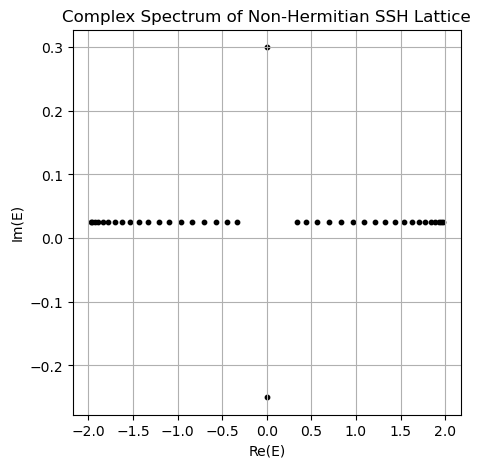

PosixPath('figures/01_theory_nonhermitian_lattices/complex_spectrum.png')

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(eigvals.real, eigvals.imag, s=10, c="black")
ax.set_xlabel("Re(E)")
ax.set_ylabel("Im(E)")
ax.set_title("Complex Spectrum of Non-Hermitian SSH Lattice")
plt.grid(True)
fig_path = save_figure(fig, NOTEBOOK_KEY, "complex_spectrum", plotting_config)
plt.show()
fig_path

## Edge Localization
Localization properties of the eigenstates are quantified by evaluating the
probability weight concentrated near the left and right boundaries of the
lattice. This measure provides a direct characterization of boundary
localization and allows systematic identification of edge-dominated modes in
the non-Hermitian spectrum.

In [14]:
def edge_localization_weights(evecs, num_cells, edge_cells=1):
    """
    Compute left and right edge localization weights
    for each eigenstate.

    Returns:
        left_weight, right_weight (arrays)
    """
    dim = 2 * num_cells

    left_sites = range(0, 2 * edge_cells)
    right_sites = range(dim - 2 * edge_cells, dim)

    left_weight = np.sum(np.abs(evecs[left_sites, :])**2, axis=0)
    right_weight = np.sum(np.abs(evecs[right_sites, :])**2, axis=0)

    return left_weight, right_weight


In [15]:
evals, evecs = la.eig(H)

left_w, right_w = edge_localization_weights(evecs, num_cells)

edge_bias = left_w - right_w

# Identify LEFT and RIGHT edge states

In [17]:
threshold = 1e-3  # small tolerance to avoid numerical noise

for i in range(len(evals)):
    if left_w[i] - right_w[i] > threshold:
        side = "LEFT edge"
    elif right_w[i] - left_w[i] > threshold:
        side = "RIGHT edge"
    else:
        side = "BULK / symmetric"

    print(
        f"State {i:3d} | "
        f"Re(E) = {evals[i].real: .4f} | "
        f"Left = {left_w[i]: .4f}, Right = {right_w[i]: .4f} → {side}"
    )


State   0 | Re(E) =  1.9753 | Left =  0.0013, Right =  0.0013 → BULK / symmetric
State   1 | Re(E) =  1.9581 | Left =  0.0052, Right =  0.0052 → BULK / symmetric
State   2 | Re(E) =  1.9295 | Left =  0.0114, Right =  0.0114 → BULK / symmetric
State   3 | Re(E) =  1.8898 | Left =  0.0192, Right =  0.0192 → BULK / symmetric
State   4 | Re(E) =  1.8392 | Left =  0.0282, Right =  0.0282 → BULK / symmetric
State   5 | Re(E) =  1.7779 | Left =  0.0375, Right =  0.0375 → BULK / symmetric
State   6 | Re(E) =  1.7064 | Left =  0.0463, Right =  0.0463 → BULK / symmetric
State   7 | Re(E) =  1.6251 | Left =  0.0540, Right =  0.0540 → BULK / symmetric
State   8 | Re(E) =  1.5345 | Left =  0.0601, Right =  0.0601 → BULK / symmetric
State   9 | Re(E) =  1.4353 | Left =  0.0639, Right =  0.0639 → BULK / symmetric
State  10 | Re(E) =  1.3279 | Left =  0.0654, Right =  0.0654 → BULK / symmetric
State  11 | Re(E) =  1.2133 | Left =  0.0645, Right =  0.0645 → BULK / symmetric
State  12 | Re(E) =  1.0923 

# Spatial Intensity Profiles of Edge-Localized Modes

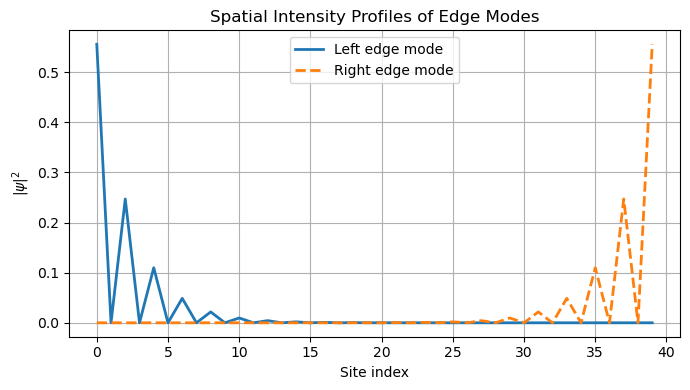

In [18]:
threshold = 1e-3

left_edge_states = np.where(left_w - right_w > threshold)[0]
right_edge_states = np.where(right_w - left_w > threshold)[0]

# Safety check
if len(left_edge_states) == 0 or len(right_edge_states) == 0:
    raise ValueError("Edge states not found. Check threshold or parameters.")

# Choose representative edge modes
# (closest to zero real energy)

left_idx = left_edge_states[
    np.argmin(np.abs(evals[left_edge_states].real))
]

right_idx = right_edge_states[
    np.argmin(np.abs(evals[right_edge_states].real))
]

# Spatial intensity profiles
# RIGHT eigenvectors

psi_left = evecs[:, left_idx]
psi_right = evecs[:, right_idx]

int_left = np.abs(psi_left)**2
int_right = np.abs(psi_right)**2

int_left /= int_left.sum()
int_right /= int_right.sum()

# Plot: LEFT & RIGHT edge modes

fig=plt.figure(figsize=(7,4))

plt.plot(int_left, lw=2, label="Left edge mode")
plt.plot(int_right, lw=2, ls="--", label="Right edge mode")

plt.xlabel("Site index")
plt.ylabel(r"$|\psi|^2$")
plt.title("Spatial Intensity Profiles of Edge Modes")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show ()
save_figure(
    fig,
    NOTEBOOK_KEY,
    "spatial_profiles_of_left_right_edge_modes",
    plotting_config
)

plt.close(fig)

### Spatial Intensity Profiles of Edge-Localized Modes

To characterize the real-space nature of the topological edge states, we examine
the **spatial intensity profiles** of representative eigenmodes of the finite
non-Hermitian SSH lattice. For a given eigenstate $\psi_n$, the probability (or
intensity) at lattice site $i$ is defined as

$$
|\psi_n(i)|^2,
$$

where $i = 0, 1, \dots, 2N-1$ labels the real-space lattice sites of the system
($N$ unit cells with two sublattice sites per cell).

In Fig.~X, we plot $|\psi_n(i)|^2$ as a function of the site index for two
representative mid-gap eigenstates identified from the energy spectrum:

- A **left edge mode** (solid blue curve), and  
- A **right edge mode** (dashed orange curve).

The left edge mode exhibits a strong intensity peak at the first lattice sites
near $i = 0$, followed by a rapid decay into the bulk. Conversely, the right edge
mode is localized near the opposite boundary at $i \approx 2N-1$ and decays
toward the interior of the lattice. In both cases, the intensity within the bulk
region is strongly suppressed, indicating negligible overlap with bulk states.

This exponential spatial decay away from the boundaries is a hallmark of
topological edge localization in the SSH model. The figure therefore provides
direct real-space confirmation that the mid-gap eigenstates observed in the
energy spectrum correspond to **boundary-localized topological modes**, rather
than extended bulk states.

Importantly, the horizontal axis represents **real-space lattice sites**, not
energy, while the vertical axis represents the local probability density. The
absence of significant intensity in the bulk region reflects the strong
confinement of the edge modes to the system boundaries.


### Left–Right Edge Localization Comparison


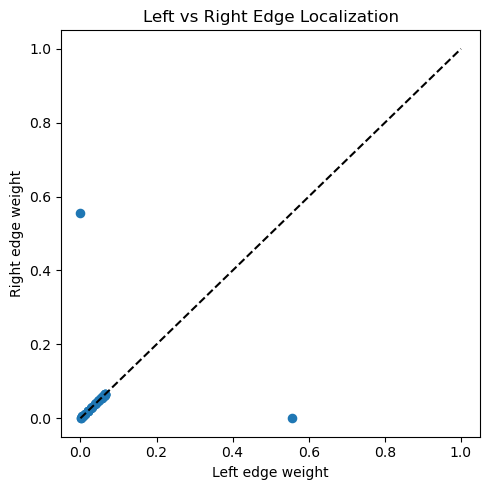

In [20]:
fig=plt.figure(figsize=(5,5))
plt.scatter(left_w, right_w, s=35)
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("Left edge weight")
plt.ylabel("Right edge weight")
plt.title("Left vs Right Edge Localization")

plt.tight_layout()
plt.show()

save_figure(
    fig,
    NOTEBOOK_KEY,
    "left_vs_right_edge_localisation",
    plotting_config
)

plt.close(fig)

Figure X compares the localization weights of eigenstates at the left and right
boundaries of the finite non-Hermitian SSH lattice. The horizontal axis represents
the **probability weight near the left edge**, while the vertical axis shows the
corresponding **probability weight near the right edge**, both computed from the
right eigenvectors of the real-space Hamiltonian.

Each point in the scatter plot corresponds to a single eigenstate of the finite
system. The dashed diagonal line indicates equal localization at both boundaries.
Eigenstates lying close to this diagonal therefore exhibit **symmetric bulk-like
behavior**, with comparable probability weight on both edges.

In contrast, points that deviate strongly from the diagonal indicate **edge
asymmetry**. States located near the horizontal axis are predominantly localized at
the **left boundary**, while those near the vertical axis are localized at the
**right boundary**. The presence of such asymmetric points provides a clear and
quantitative identification of boundary-localized modes.

This representation allows a direct distinction between bulk states and edge
states, as well as an unambiguous determination of **which boundary dominates the
localization** of a given eigenmode. The observed separation of left- and
right-dominated states is consistent with the existence of topological edge modes
in the finite SSH lattice.


### Boundary Dominance of Eigenstates



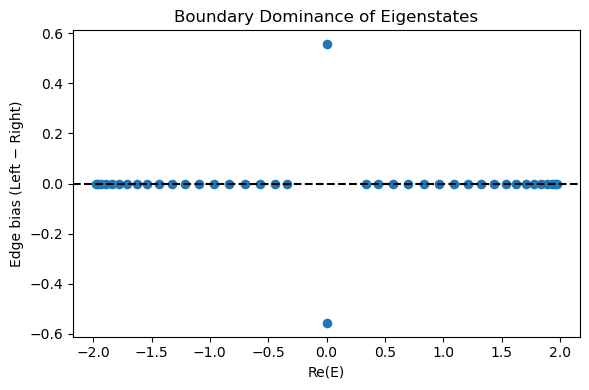

In [21]:
fig=plt.figure(figsize=(6,4))
plt.scatter(evals.real, edge_bias, s=35)
plt.axhline(0, color='k', ls='--')

plt.xlabel("Re(E)")
plt.ylabel("Edge bias (Left − Right)")
plt.title("Boundary Dominance of Eigenstates")

plt.tight_layout()
fig_path = save_figure(fig, NOTEBOOK_KEY, "boundary_dominance_of_eigenstates", plotting_config)
plt.show ()
save_figure(
    fig,
    NOTEBOOK_KEY,
    "boundary_dominance_of_eigenstates",
    plotting_config
)

plt.close(fig)

Figure X visualizes the boundary dominance of the eigenstates of the finite
non-Hermitian SSH lattice by plotting the **edge bias** as a function of the real
part of the eigenenergy. The edge bias is defined as the difference between the
probability weight near the left and right boundaries,

$$
\text{Edge bias} = W_{\mathrm{left}} - W_{\mathrm{right}},
$$

where \( W_{\mathrm{left}} \) and \( W_{\mathrm{right}} \) denote the integrated
probability density of a given eigenstate near the left and right edges,
respectively.

Each point in the plot corresponds to a single eigenstate of the finite system.
States with an edge bias close to zero exhibit nearly equal weight on both
boundaries and are therefore identified as **bulk-like states**. In contrast,
states with a large positive edge bias are predominantly localized at the **left
boundary**, while those with a large negative edge bias are localized at the
**right boundary**.

The figure shows that the majority of eigenstates cluster around zero edge bias,
indicating symmetric bulk localization. However, two eigenstates near the center
of the energy spectrum display pronounced positive and negative edge bias. These
states correspond to **mid-gap edge modes**, with one localized at the left edge
and the other at the right edge of the lattice.

This clear separation between bulk states and boundary-dominated states provides
direct real-space evidence for the existence of topological edge modes in the
finite SSH system. The absence of a global bias affecting all states further
confirms that the observed boundary localization arises from topology rather than
from non-Hermitian skin effects.
